In [69]:
import pandas as pd

df = pd.read_excel('Contact_Awards_Slim_Cleaned.xlsx')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1743 entries, 0 to 1742
Columns: 198 entries, total_obligated_amount to last_modified_date
dtypes: datetime64[us](4), float64(13), int64(2), object(2), str(177)
memory usage: 2.6+ MB


In [70]:
pd.set_option("display.max_rows", None)
print(df.value_counts("recipient_name"))

recipient_name
SKYDIO                                           578
AEROVIRONMENT INC                                404
PALANTIR TECHNOLOGIES INC                        382
ANDURIL INDUSTRIES, INC.                         273
KRATOS DEFENSE & ROCKET SUPPORT SERVICES, INC     72
SHIELD AI INC                                     30
SARONIC TECHNOLOGIES, INC                          3
CHAOS INDUSTRIES, INC.                             1
Name: count, dtype: int64


In [71]:
df.groupby("recipient_name")['total_obligated_amount'].sum().sort_values(ascending=False)

recipient_name
PALANTIR TECHNOLOGIES INC                        4.047586e+09
ANDURIL INDUSTRIES, INC.                         2.367155e+09
AEROVIRONMENT INC                                2.284535e+09
KRATOS DEFENSE & ROCKET SUPPORT SERVICES, INC    2.474359e+08
SKYDIO                                           1.269791e+08
SHIELD AI INC                                    6.530411e+07
CHAOS INDUSTRIES, INC.                           1.717503e+06
SARONIC TECHNOLOGIES, INC                        5.000000e+02
Name: total_obligated_amount, dtype: float64

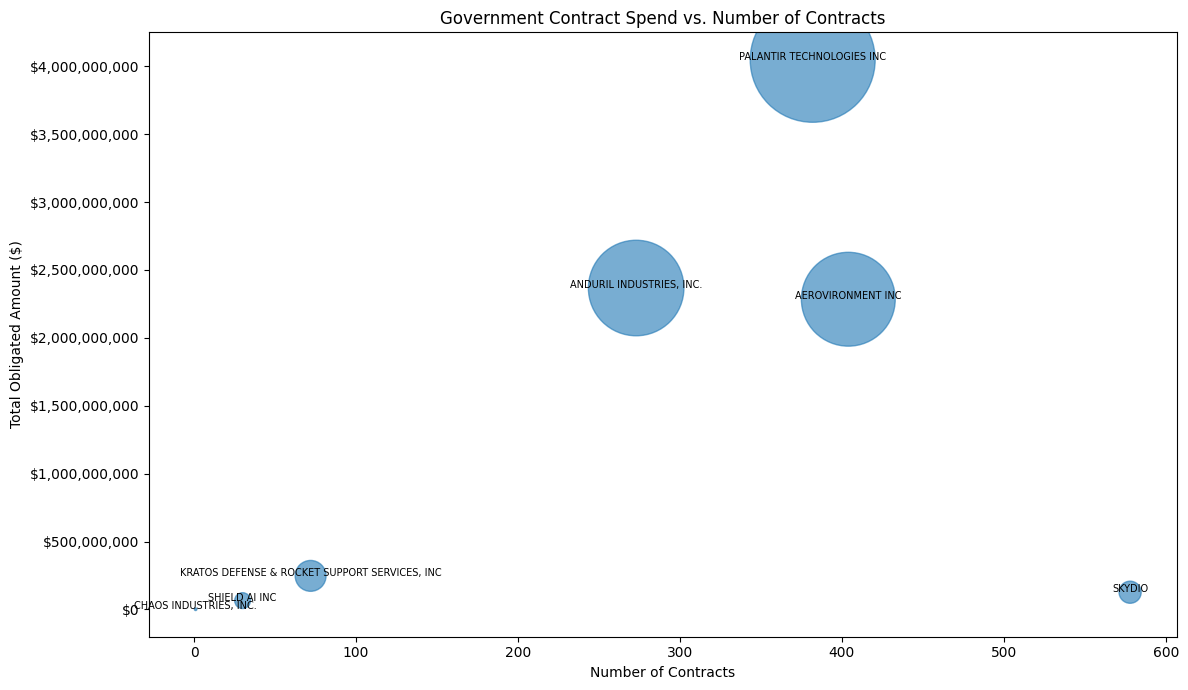

In [73]:
import matplotlib.pyplot as plt

# Build the summary data
summary = df.groupby("recipient_name").agg(
    total_spend=("total_obligated_amount", "sum"),
    contract_count=("total_obligated_amount", "count")
).reset_index()

# Drop tiny players to keep it readable
summary = summary[summary["total_spend"] > 1_000_000]

fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(
    summary["contract_count"],
    summary["total_spend"],
    s=summary["total_spend"] / 500_000,  # bubble size = spend magnitude
    alpha=0.6
)

# Label each bubble
for _, row in summary.iterrows():
    ax.annotate(row["recipient_name"], (row["contract_count"], row["total_spend"]),
                fontsize=7, ha="center")

ax.set_xlabel("Number of Contracts")
ax.set_ylabel("Total Obligated Amount ($)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_title("Government Contract Spend vs. Number of Contracts")
plt.tight_layout()
plt.show()


In [ ]:
contracts_per_year = df.groupby("award_year")["total_obligated_amount"].count()



,total_obligated_amount,total_outlayed_amount,current_total_value_of_award,potential_total_value_of_award,award_year,award_base_action_date,period_of_performance_start_date,period_of_performance_current_end_date,period_of_performance_potential_end_date,awarding_agency_name,...,highly_compensated_officer_2_name,highly_compensated_officer_2_amount,highly_compensated_officer_3_name,highly_compensated_officer_3_amount,highly_compensated_officer_4_name,highly_compensated_officer_4_amount,highly_compensated_officer_5_name,highly_compensated_officer_5_amount,usaspending_permalink,last_modified_date
0,20626003.00,NaN,NaN,NaN,2010,2010-03-01,2010-03-01,2016-09-30,2016-09-30,Department of Defense,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/CONT_AWD_FA8...,2016-06-15 15:50:22+00
1,0.00,NaN,NaN,39267040.00,2011,2011-03-01,2011-03-01,NaT,NaT,Department of Defense,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/CONT_IDV_W31...,2018-07-25 15:46:29+00
2,18150080.00,NaN,18150080.00,18150080.00,2011,2011-04-26,2011-04-25,2020-04-21,2020-04-21,Department of Defense,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/CONT_AWD_L60...,2022-10-29 13:15:49+00
3,91302406.78,NaN,22862733.98,-90090.02,2011,2011-04-28,2011-04-28,2016-05-16,2016-05-16,Department of Defense,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/CONT_AWD_000...,2020-02-28 10:34:40+00
4,1692184.80,NaN,1692184.80,1692184.80,2011,2011-12-09,2011-12-12,2016-12-11,2016-12-11,Department of Health and Human Services,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/CONT_AWD_HHS...,2022-04-13 15:56:02+00


In [ ]:
df_dw = pd.read_excel("Contact_Cleaned_Datawrapper.xlsx")


In [81]:
df_wide = df_dw.pivot_table(
    index="recipient_name",
    columns="award_year",
    values="total_obligated_amount",
    aggfunc="sum"
).reset_index()

df_wide.to_csv("Contracts_datawrapper_wide")